[2026-07-27 19:16:47] [info     ] 计算因子: 2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[因子计算] 区间: 2024-01-01 ~ 2024-12-31  |  回看: 2022-11-27
[1/6] 获取财务数据(PIT)...
[1/6] 财务数据: 15968 条
[2/6] 获取日线行情 + 计算动量信号...
[2/6] 日线数据: 611910 条  |  动量信号已就绪
[3/6] 计算日收益率和滚动Beta(252日)...
[3/6] Beta: mean=1.002  std=0.342
[4/6] 合并财务与行情数据(merge_asof)...
[4/6] 合并后: 290541 条
[5/6] 计算价值因子(EPV/NAV/WACC)...
[5/6] 价值因子: mean=0.7946  std=0.2579  盈利占比=83.8%
[6/6] 动量增强合成 + 股票池对齐...
[6/6] 合成因子: mean=0.5004  std=0.1786
[6/6] 动量分量覆盖率: mom=96%  rev=100%
[6/6] 输出: 242000条 | 242交易日 | 1206只股票 | 覆盖度99.9%
[2026-07-27 19:16:55] [info     ] 读取因子库...
[2026-07-27 19:16:55] [info     ] 评估因子...
[2026-07-27 19:16:55] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-27 19:16:59] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-27 19:16:59] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-27 19:16:59] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-27

时段,IC
2024-01-15~2024-02-08,-0.0023
2024-09-24~2024-10-08,0.0137

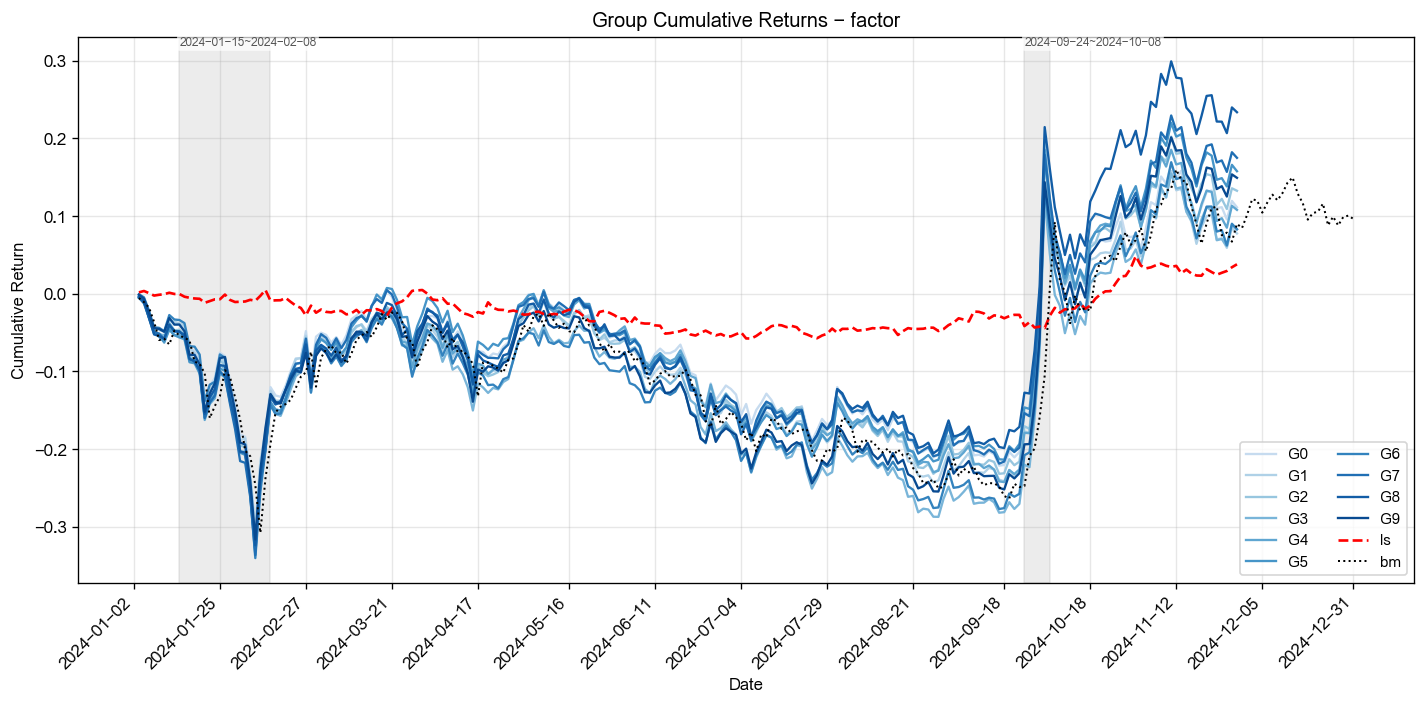
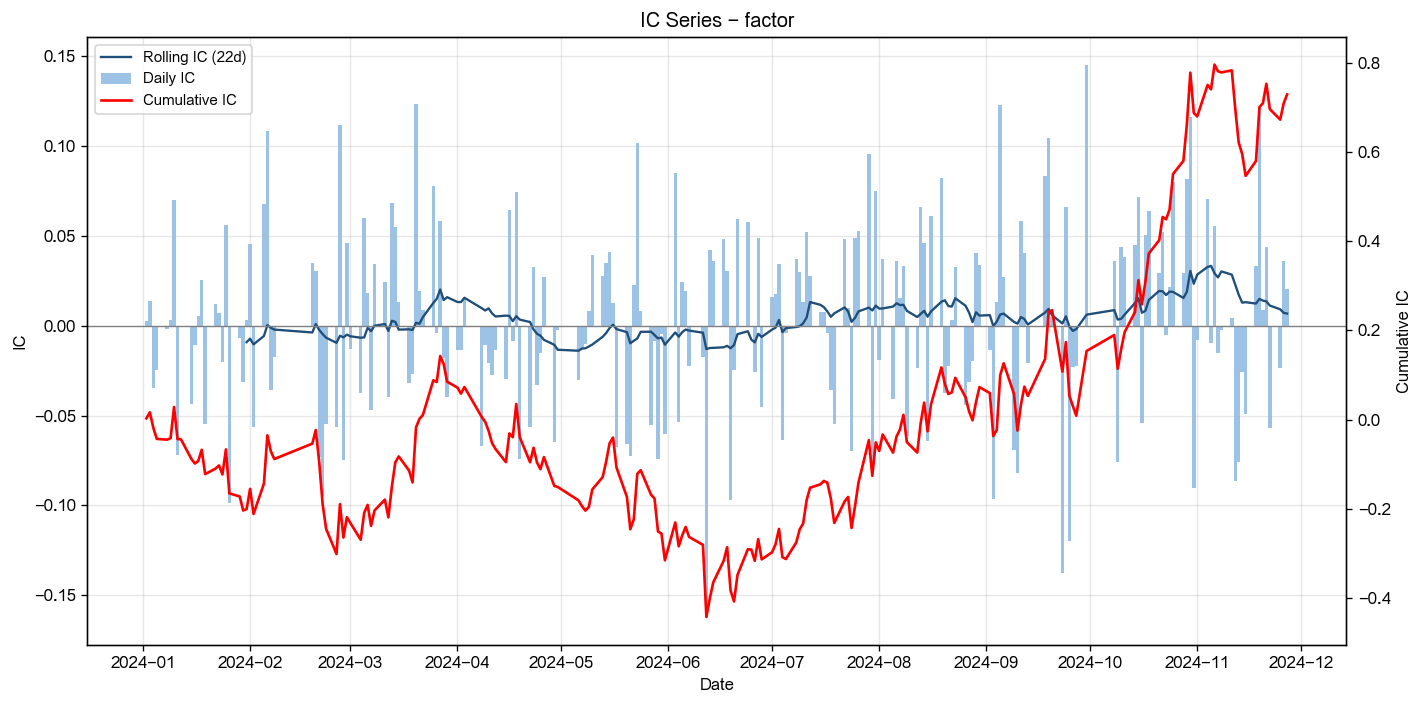
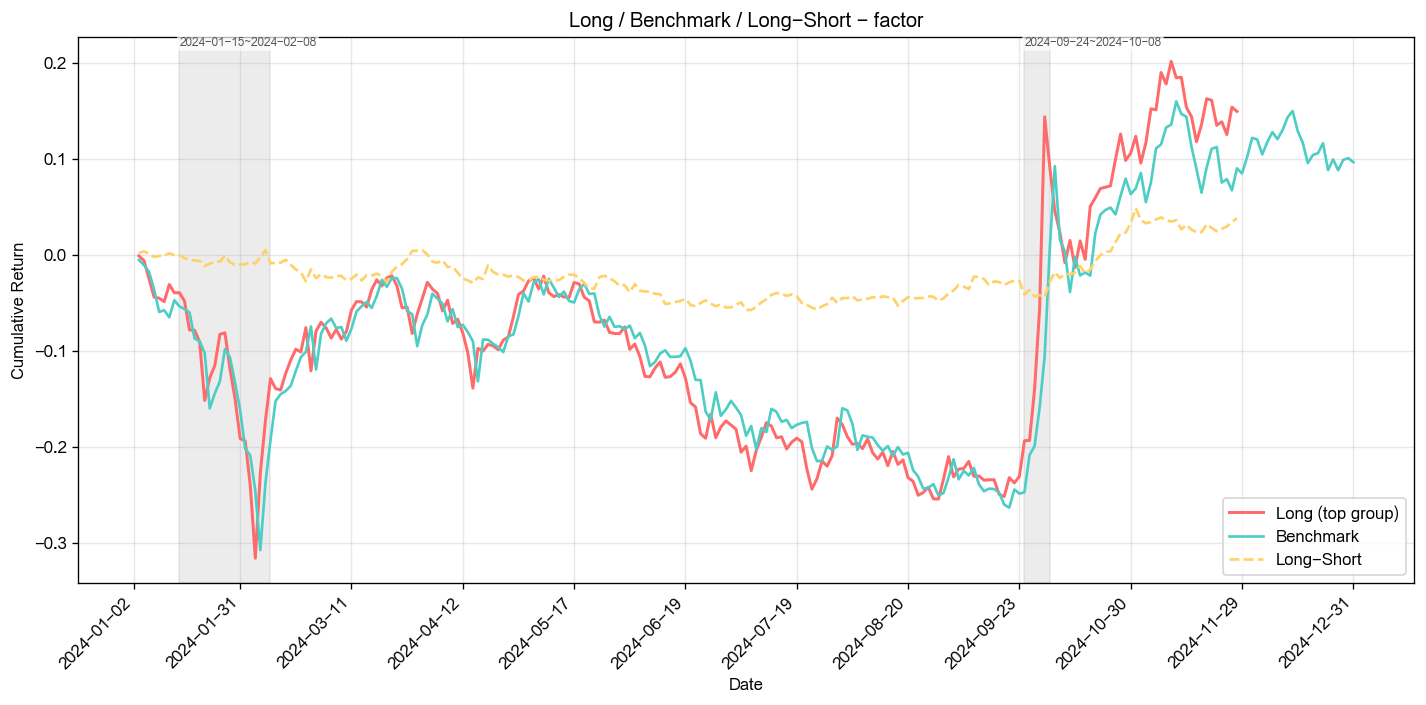
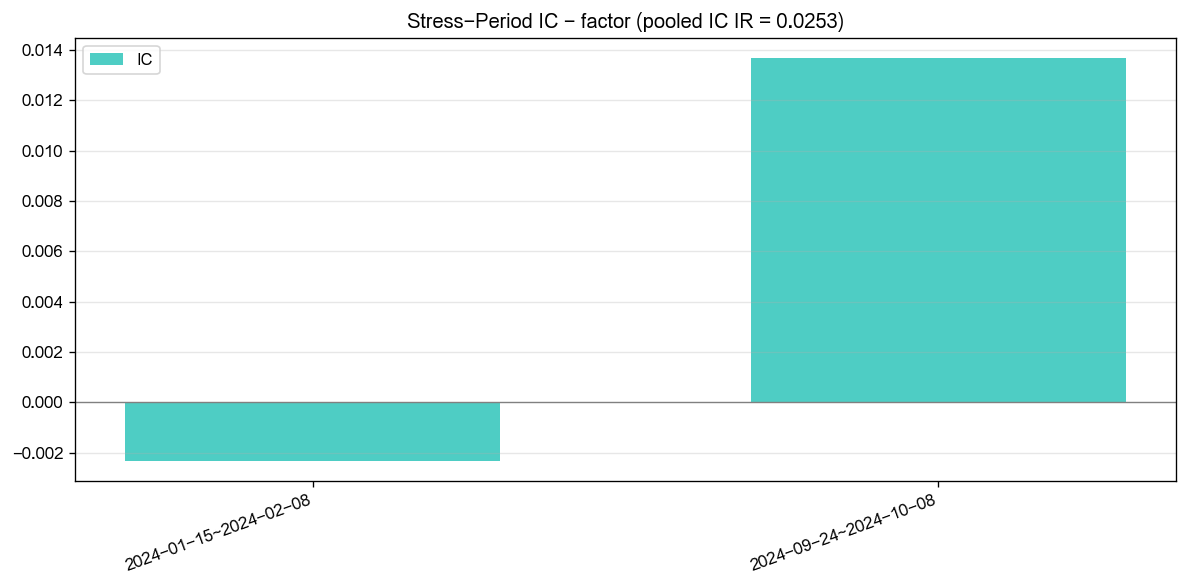
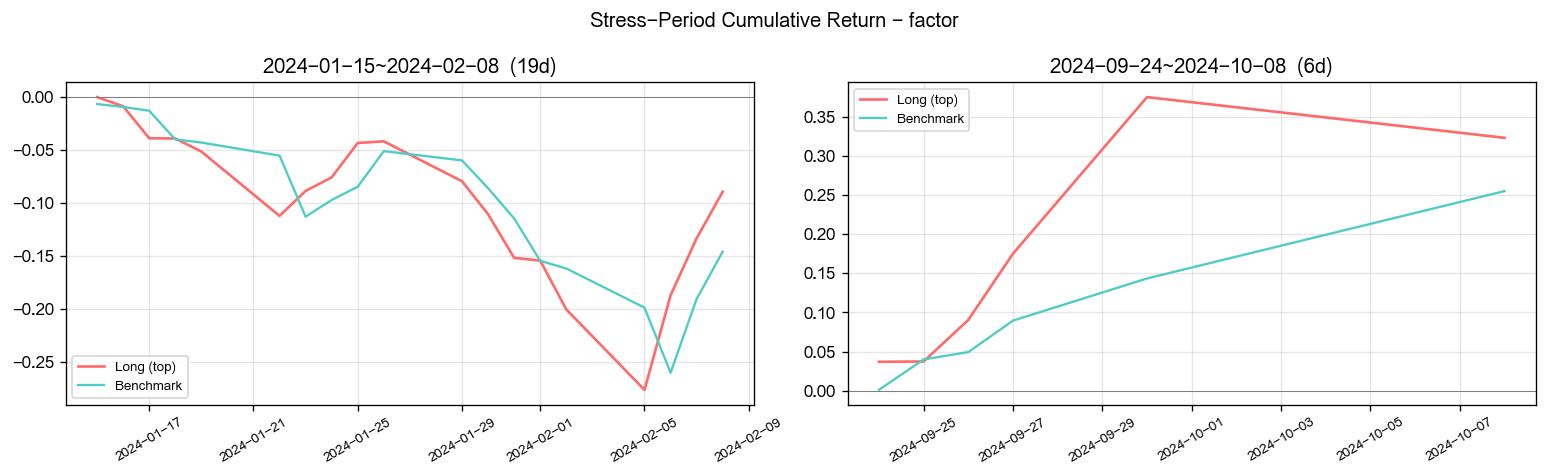

[2026-07-27 19:17:16] [info     ] ========== 因子池回归 ==========
[2026-07-27 19:17:16] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-27 19:17:17] [info     ] 获取收益率数据, 耗时: 0.8993 秒
[2026-07-27 19:17:17] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.1674 秒
[2026-07-27 19:17:17] [info     ] 统计 回归结果, 耗时: 0.0935 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9792,0.0462,0.0233,1.0000
2,amount,1.7304,0.0186,0.0107,1.0000
3,netflow_amount_rate_main,1.5265,0.0100,0.0065,1.0000
4,netflow_amount_main,1.5127,0.0252,0.0166,1.0000
5,gross_profit_rate_ttm,1.4820,0.0070,0.0047,1.0000
6,net_profit_rate_ttm,1.4678,0.0041,0.0028,0.8000
7,bias_20,1.4309,0.0293,0.0205,0.9000
8,pb,1.4138,0.0089,0.0063,1.0000
9,list_days,1.3802,0.0113,0.0082,0.9000
10,cci_14,1.3577,0.0340,0.0251,1.0000

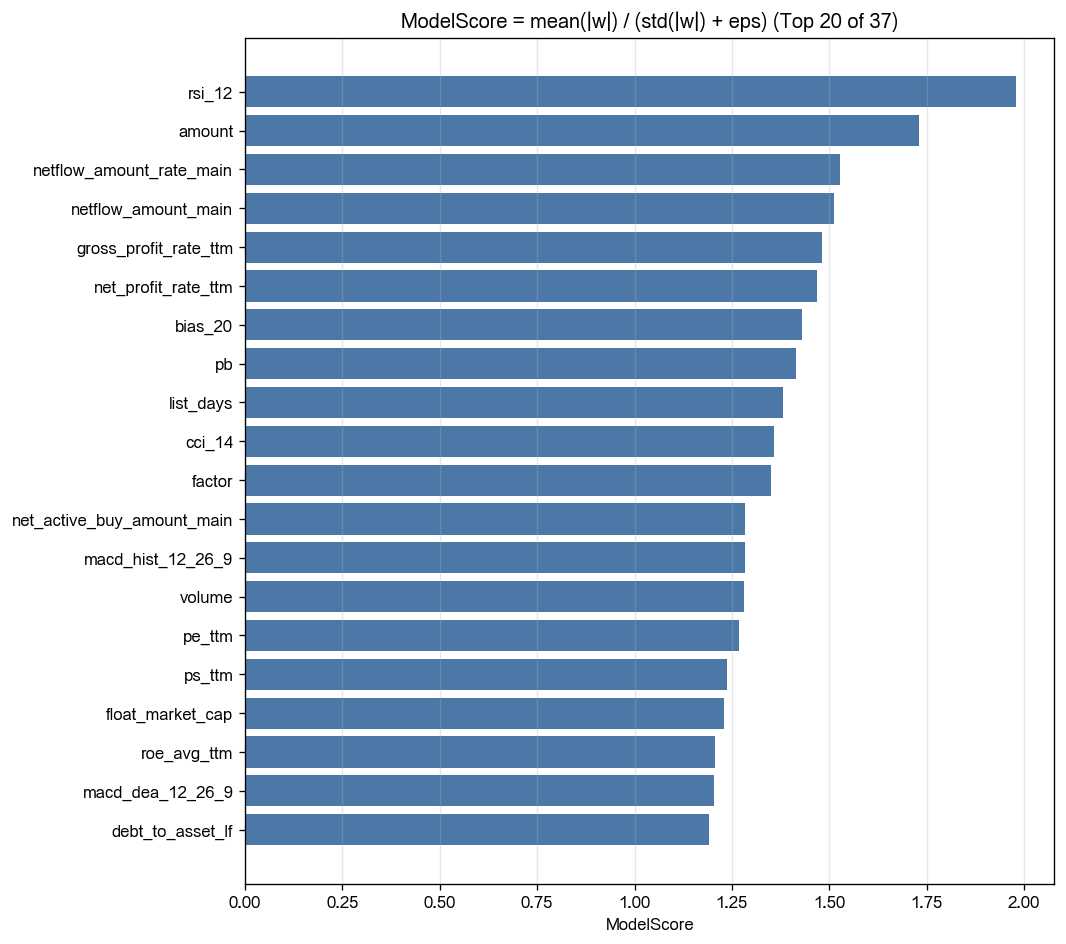
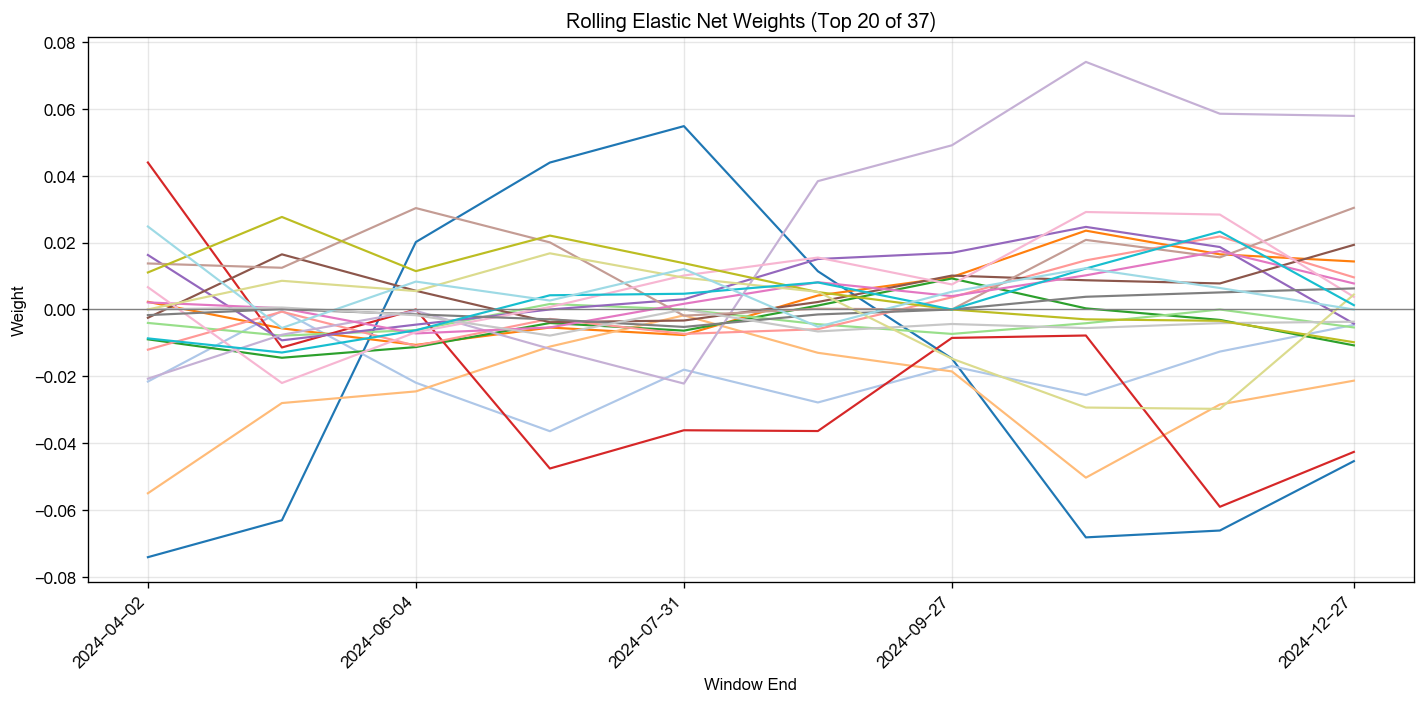
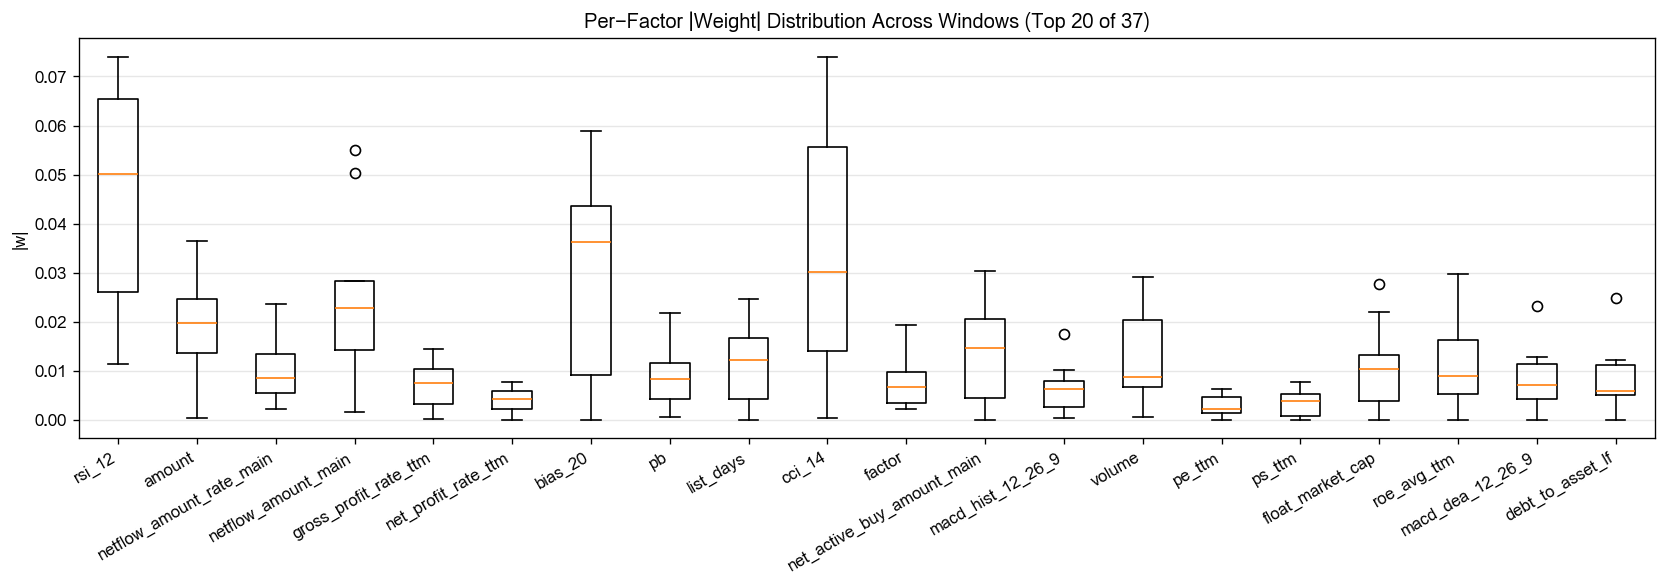
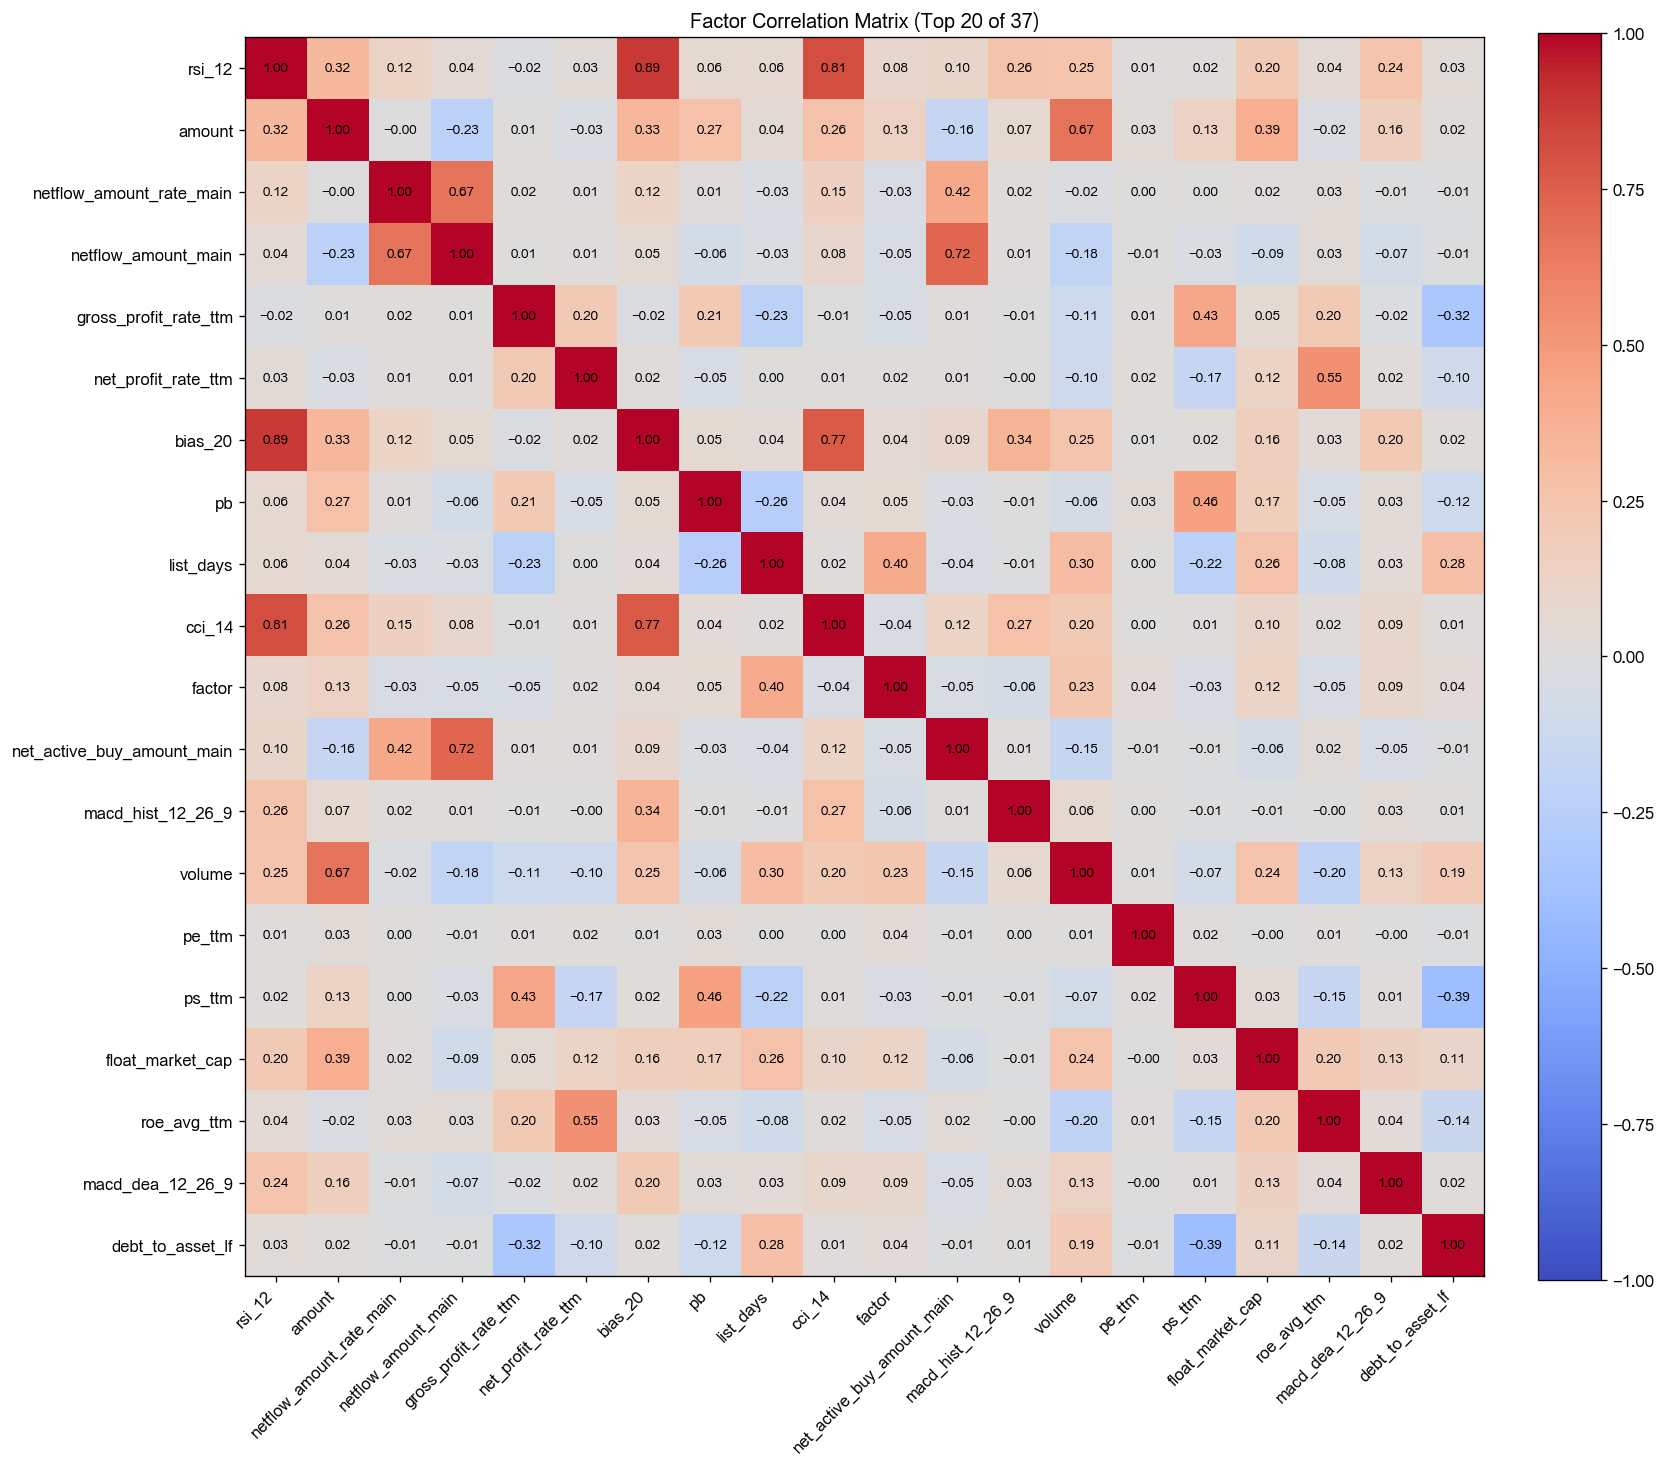

[2026-07-27 19:17:20] [warning  ] 返回的Outputs实例(size=35180417) 大于 64K, 将不会被缓存
[2026-07-27 19:17:20] [info     ] bigalpha_eval.v4 运行完成 [21.160s].
[2026-07-27 19:17:20] [info     ] 评估完成


In [1]:
def main(datasources, start_date, end_date):
    """
    真实价值动量增强因子 — BigAlpha 2026 传统量化赛道

    核心逻辑（保持不变）：
      企业真实价值 = (NAV + EPV) / 2  （盈利企业）
      企业真实价值 = NAV              （亏损企业）
      价值因子 = (总市值 - 真实价值) / 总市值

    动量增强（新增）：
      60日动量: 中期趋势追随，动量效应在A股中期有效
      5日反转:  短期均值回复，捕捉超卖反弹（类似RSI逻辑）
      最终因子 = 0.50×价值排名 + 0.30×动量排名 + 0.20×反转排名

    参数:
        datasources (dict): 平台注入的数据源映射
        start_date  (str):  起始日期
        end_date    (str):  截止日期

    返回:
        pd.DataFrame: 三列 ['date', 'instrument', 'factor']，不含 inf
    """
    # ================================================================
    # 导入依赖
    # ================================================================
    import dai
    import pandas as pd
    import numpy as np
    import warnings
    warnings.filterwarnings('ignore')

    # ================================================================
    # 全局参数
    # ================================================================
    TAX_RATE      = 0.25
    RISK_FREE     = 0.025
    MRP           = 0.06
    COST_OF_DEBT  = 0.04
    BETA_WINDOW   = 252
    NAV_ADJ       = 1.0

    # 动量增强参数
    MOM_WINDOW    = 60    # 中期动量窗口（交易日）
    REV_WINDOW    = 5     # 短期反转窗口（交易日）
    W_VALUE       = 0.50  # 价值权重
    W_MOM         = 0.30  # 动量权重
    W_REV         = 0.20  # 反转权重

    # ================================================================
    # 日期预处理
    # ================================================================
    start_dt    = pd.Timestamp(start_date)
    end_dt      = pd.Timestamp(end_date)
    lookback_dt = start_dt - pd.DateOffset(days=400)  # 动量需要60日+安全边际

    start_str    = start_dt.strftime('%Y-%m-%d')
    end_str      = end_dt.strftime('%Y-%m-%d')
    lookback_str = lookback_dt.strftime('%Y-%m-%d')

    print(f"[因子计算] 区间: {start_str} ~ {end_str}  |  回看: {lookback_str}")

    # ================================================================
    # 步骤1: 获取财务数据 (PIT) — 保持原有逻辑
    # ================================================================
    print("[1/6] 获取财务数据(PIT)...")
    financial_table = datasources["financial"]

    fin_sql = f"""
        SELECT
            date          AS fin_date,
            instrument,
            report_date,
            total_assets,
            total_liabilities,
            operating_profit,
            total_owner_equity,
            latest_shares
        FROM {financial_table}
        WHERE category = 'lf'
        ORDER BY instrument, date
    """
    fin_raw = dai.query(fin_sql, filters={'date': [lookback_str, end_str]}).df()

    for col in ['total_assets','total_liabilities','operating_profit',
                'total_owner_equity','latest_shares']:
        if col in fin_raw.columns:
            fin_raw[col] = pd.to_numeric(fin_raw[col], errors='coerce')
    fin_raw = fin_raw.dropna(subset=['total_assets', 'total_liabilities'])
    fin_raw = fin_raw[fin_raw['total_assets'] > 0]
    fin_raw = fin_raw.sort_values(['instrument','fin_date','report_date'])
    fin_raw = fin_raw.drop_duplicates(subset=['instrument','fin_date'], keep='last')
    print(f"[1/6] 财务数据: {len(fin_raw)} 条")

    # ================================================================
    # 步骤2: 获取日线行情数据 + 计算动量/反转信号
    # ================================================================
    print("[2/6] 获取日线行情 + 计算动量信号...")
    bar_sql = f"""
        SELECT date, instrument, close, amount, volume
        FROM bigalpha_2026_bar1d
        ORDER BY instrument, date
    """
    bar_raw = dai.query(bar_sql, filters={'date': [lookback_str, end_str]}).df()
    bar_raw['close'] = pd.to_numeric(bar_raw['close'], errors='coerce')
    bar_raw = bar_raw.dropna(subset=['close'])
    bar_raw = bar_raw[bar_raw['close'] > 0]
    bar_raw['date'] = pd.to_datetime(bar_raw['date'])
    bar_raw = bar_raw.sort_values(['instrument','date'])

    # ---- 动量信号（在bar_raw上计算，利用完整回看数据） ----
    # 60日动量: 中期趋势追随（A股中期动量效应有效）
    # 使用 shift(1) 避免使用当日收盘价（杜绝未来信息）
    bar_raw['mom_60d'] = (
        bar_raw.groupby('instrument')['close']
        .transform(lambda x: x.shift(1) / x.shift(MOM_WINDOW + 1) - 1)
    )
    # 5日反转: 短期均值回复（类似 RSI 超卖反弹逻辑）
    bar_raw['rev_5d'] = (
        bar_raw.groupby('instrument')['close']
        .transform(lambda x: -(x.shift(1) / x.shift(REV_WINDOW + 1) - 1))
    )
    print(f"[2/6] 日线数据: {len(bar_raw)} 条  |  动量信号已就绪")

    # ================================================================
    # 步骤3: 日收益率 + Beta (252日滚动窗口) — 保持原有逻辑
    # ================================================================
    print("[3/6] 计算日收益率和滚动Beta(252日)...")
    bar_raw['ret'] = bar_raw.groupby('instrument')['close'].pct_change()
    bar_raw = bar_raw.dropna(subset=['ret'])

    mkt_ret = bar_raw.groupby('date')['ret'].mean().reset_index()
    mkt_ret.columns = ['date','mkt_ret']
    ret_df = bar_raw[['date','instrument','ret','close','mom_60d','rev_5d']].merge(
        mkt_ret, on='date', how='left'
    )

    def _rolling_beta(grp):
        grp = grp.sort_values('date')
        cov = grp['ret'].rolling(BETA_WINDOW, min_periods=60).cov(grp['mkt_ret'])
        var = grp['mkt_ret'].rolling(BETA_WINDOW, min_periods=60).var()
        beta = (cov / var).replace([np.inf, -np.inf], np.nan).clip(0, 3)
        return beta

    ret_df['beta'] = ret_df.groupby('instrument', group_keys=False).apply(_rolling_beta)
    ret_df['beta'] = ret_df['beta'].fillna(1.0)
    print(f"[3/6] Beta: mean={ret_df['beta'].mean():.3f}  std={ret_df['beta'].std():.3f}")

    # ================================================================
    # 步骤4: 合并财务数据 + 行情数据 (PIT前向填充) — 保持原有逻辑
    # ================================================================
    print("[4/6] 合并财务与行情数据(merge_asof)...")
    fin_cols = ['instrument','fin_date','total_assets','total_liabilities',
                'operating_profit','latest_shares']
    fin_merge = fin_raw[fin_cols].copy()
    fin_merge['fin_date'] = pd.to_datetime(fin_merge['fin_date'])

    daily = ret_df[ret_df['date'] >= start_dt].copy()
    daily  = daily.sort_values(['instrument','date'])
    fin_merge = fin_merge.sort_values(['instrument','fin_date'])

    merged = pd.merge_asof(
        daily.sort_values('date'),
        fin_merge.sort_values('fin_date'),
        by='instrument',
        left_on='date', right_on='fin_date',
        direction='backward',
        allow_exact_matches=True,
    )
    merged = merged.dropna(subset=['total_assets','total_liabilities'])
    print(f"[4/6] 合并后: {len(merged)} 条")

    # ================================================================
    # 步骤5: 计算价值因子 — 保持原有逻辑不变
    # ================================================================
    print("[5/6] 计算价值因子(EPV/NAV/WACC)...")

    merged['market_cap'] = merged['close'] * merged['latest_shares']
    merged = merged[(merged['market_cap'] > 0) & (merged['latest_shares'] > 0)]

    E    = merged['market_cap'].values
    D    = merged['total_liabilities'].values
    V    = E + D
    beta = merged['beta'].values

    Re = RISK_FREE + beta * MRP
    with np.errstate(divide='ignore', invalid='ignore'):
        wacc = np.where(V > 0, (E/V)*Re + (D/V)*COST_OF_DEBT*(1-TAX_RATE), 0.10)
    wacc = np.clip(wacc, 0.03, 0.20)

    net_asset = np.maximum(merged['total_assets'].values - D, 0)
    nav = net_asset * NAV_ADJ

    op_profit     = merged['operating_profit'].fillna(0).values
    op_profit_pos = np.maximum(op_profit, 0)
    after_tax     = op_profit_pos * (1 - TAX_RATE)
    with np.errstate(divide='ignore', invalid='ignore'):
        epv = np.where(wacc > 0, after_tax / wacc, 0)
    epv = np.clip(epv, 0, nav * 10 + 1e10)

    is_profitable = op_profit > 0
    true_value = np.where(is_profitable, (nav + epv) / 2.0, nav)

    with np.errstate(divide='ignore', invalid='ignore'):
        factor_raw = np.where(
            merged['market_cap'].values > 0,
            (merged['market_cap'].values - true_value) / merged['market_cap'].values,
            0,
        )
    merged['value_factor'] = np.clip(factor_raw, -5, 0.99)
    print(f"[5/6] 价值因子: mean={merged['value_factor'].mean():.4f}"
          f"  std={merged['value_factor'].std():.4f}"
          f"  盈利占比={is_profitable.mean()*100:.1f}%")

    # ================================================================
    # 步骤6: 动量增强 — 截面排名合成最终因子
    # 统计方法: 每日截面内百分位排名，消除量纲差异后加权合成
    #   value_rank: 价值排名（原因子方向: 高溢价=高排名）
    #   mom_rank:   60日动量排名（高动量=高排名，趋势追随）
    #   rev_rank:   5日反转排名（超卖反弹=高排名，均值回复）
    # ================================================================
    print("[6/6] 动量增强合成 + 股票池对齐...")

    # 截面百分位排名
    merged['value_rank'] = merged.groupby('date')['value_factor'].transform(
        lambda x: x.rank(pct=True)
    )
    merged['mom_rank'] = merged.groupby('date')['mom_60d'].transform(
        lambda x: x.rank(pct=True)
    )
    merged['rev_rank'] = merged.groupby('date')['rev_5d'].transform(
        lambda x: x.rank(pct=True)
    )

    # 加权合成最终因子
    merged['factor'] = (
        W_VALUE * merged['value_rank'].fillna(0.5) +
        W_MOM   * merged['mom_rank'].fillna(0.5) +
        W_REV   * merged['rev_rank'].fillna(0.5)
    )

    # 统计各分量贡献
    print(f"[6/6] 合成因子: mean={merged['factor'].mean():.4f}"
          f"  std={merged['factor'].std():.4f}")
    print(f"[6/6] 动量分量覆盖率: mom={merged['mom_60d'].notna().mean()*100:.0f}%"
          f"  rev={merged['rev_5d'].notna().mean()*100:.0f}%")


    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_str, end_str]},
    ).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date'])
    merged['date']   = pd.to_datetime(merged['date'])

    output = pd.merge(
        merged[['date','instrument','factor']],
        stk_pool,
        how='right', on=['date','instrument'],
    )
    output = output.sort_values(['date','instrument']).reset_index(drop=True)
    output = output.drop_duplicates(subset=['date','instrument'], keep='last')
    output['factor'] = output['factor'].replace([np.inf, -np.inf], np.nan)

    n_dates  = output['date'].nunique()
    n_stocks = output['instrument'].nunique()
    coverage = output['factor'].notna().mean() * 100
    print(f"[6/6] 输出: {len(output)}条 | {n_dates}交易日 | {n_stocks}只股票 | 覆盖度{coverage:.1f}%")
    if coverage < 60:
        print(f"  ⚠ 覆盖度<60%，请检查数据质量")

    return output


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        'financial': 'bigalpha_2026_financial',
        'bar1m':     'bigalpha_2026_stock_bar1m',
    }
    start_date = '2024-01-01 00:00:00'
    end_date   = '2024-12-31 23:59:59'

    logger.info(f"计算因子: {start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info("读取因子库...")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    logger.info("评估因子...")
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
    logger.info("评估完成")
